# Environment

In [1]:
import os
os.chdir("..")

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from src.utils.map import SYMPTOM_MAP

## Load Data

In [3]:
amive = pd.read_csv("../shared/Datasets/amive/amive_sentences.csv")

# Filtered Depressive Symptoms

In [4]:
EXCLUDE = {
    "Postagem com possível perfil depressivo",
    "Fator de risco",
    "Fator protetivo, cuidado em saúde e bem-estar",
}

In [5]:
amive = amive[~amive["SYMPTOM"].isin(EXCLUDE)]
amive = amive.dropna(subset=["SYMPTOM"])

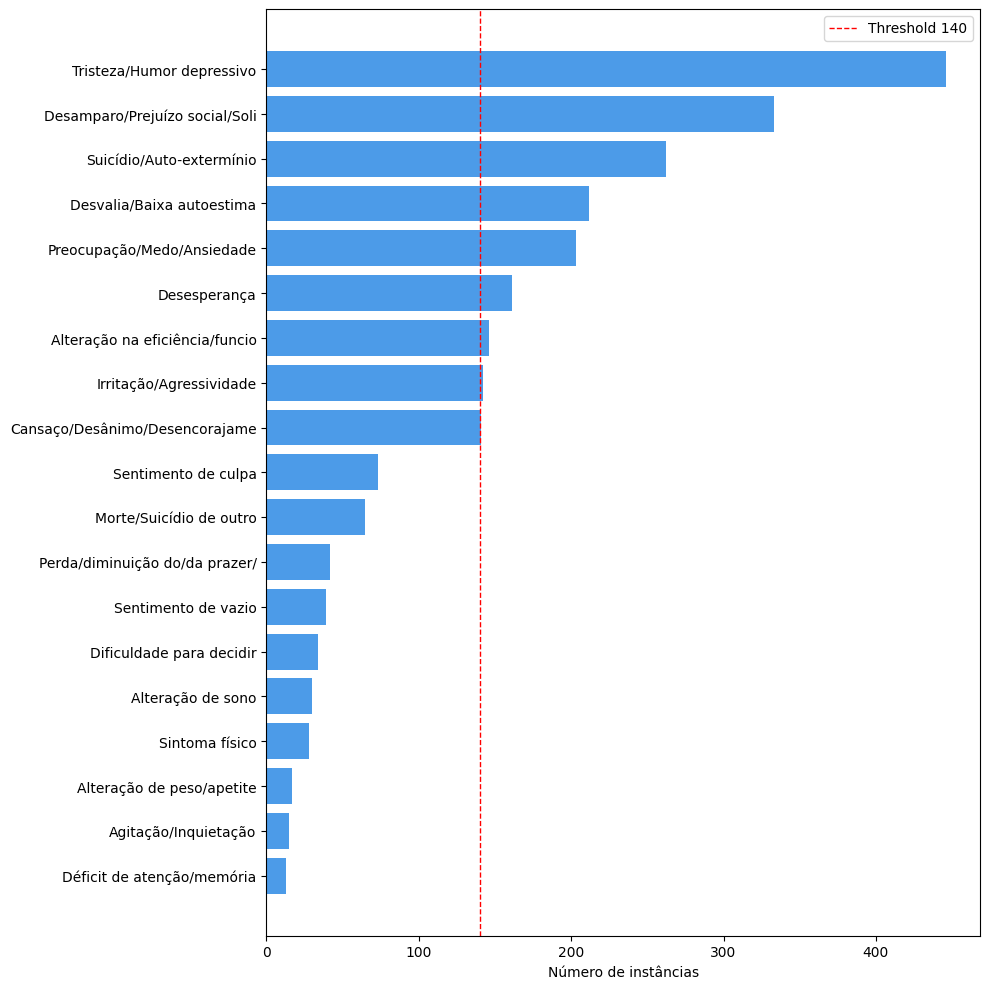

In [7]:
counts = amive["SYMPTOM"].value_counts().reset_index()
counts.columns = ["SYMPTOM", "COUNT"]
counts["label"] = [f"{s[:30]}" for i, s in enumerate(counts["SYMPTOM"])]

fig, ax = plt.subplots(figsize=(10, 10))
ax.barh(counts["label"], counts["COUNT"], color="#4C9BE8")
ax.axvline(x=140, color="red", linestyle="--", linewidth=1, label="Threshold 140")
ax.set_xlabel("Número de instâncias")
ax.invert_yaxis()
ax.legend()
plt.tight_layout()
plt.show()

In [8]:
valid_symptoms = counts[counts["COUNT"] >= 140]["SYMPTOM"]
amive = amive[amive["SYMPTOM"].isin(valid_symptoms)]

In [10]:
counts

,SYMPTOM,COUNT,label
0,Tristeza/Humor depressivo,446,Tristeza/Humor depressivo
1,Desamparo/Prejuízo social/Solidão,333,Desamparo/Prejuízo social/Soli
2,Suicídio/Auto-extermínio,262,Suicídio/Auto-extermínio
3,Desvalia/Baixa autoestima,212,Desvalia/Baixa autoestima
4,Preocupação/Medo/Ansiedade,203,Preocupação/Medo/Ansiedade
5,Desesperança,161,Desesperança
6,Alteração na eficiência/funcionalidade,146,Alteração na eficiência/funcio
7,Irritação/Agressividade,142,Irritação/Agressividade
8,Cansaço/Desânimo/Desencorajamento/Fadiga/Perda...,141,Cansaço/Desânimo/Desencorajame
9,Sentimento de culpa,73,Sentimento de culpa


In [9]:
{s: str(i + 1) for i, s in enumerate(valid_symptoms)}

{'Tristeza/Humor depressivo': '1',
 'Desamparo/Prejuízo social/Solidão': '2',
 'Suicídio/Auto-extermínio': '3',
 'Desvalia/Baixa autoestima': '4',
 'Preocupação/Medo/Ansiedade': '5',
 'Desesperança': '6',
 'Alteração na eficiência/funcionalidade': '7',
 'Irritação/Agressividade': '8',
 'Cansaço/Desânimo/Desencorajamento/Fadiga/Perda de energia/Lentificação': '9'}

In [9]:
amive = (
    amive.groupby(["DOCNO", "TEXT"])["SYMPTOM"]
    .apply(lambda syms: ",".join(sorted(set(SYMPTOM_MAP[s] for s in syms), key=int)))
    .reset_index()
)

In [10]:
dummies = amive["SYMPTOM"].str.get_dummies(sep=",")
dummies = dummies[sorted(dummies.columns, key=lambda x: int(x))]
amive = pd.concat([amive[["DOCNO", "TEXT"]], dummies], axis=1)

In [11]:
amive

,DOCNO,TEXT,1,2,3,4,5,6,7,8,9
0,100_10,"Mas , quando estou sozinho comigo mesmo , perc...",0,1,0,0,0,0,0,0,0
1,100_11,Me sinto cansado .,0,0,0,0,0,0,0,0,1
2,100_12,Sinto que minha vida está sendo desperdiçada .,0,0,0,1,0,1,0,0,1
3,100_13,"As vezes quero dar um grito bem forte , pular ...",1,0,0,0,1,1,0,0,0
4,100_14,"Mas , não sei como . . .",0,0,0,0,0,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...
1535,99_12,Foda-se .,0,0,0,0,0,0,0,1,0
1536,99_15,"Muitos pensam que o suicídio é egoísmo , mas n...",0,0,0,0,0,1,0,0,0
1537,99_16,"Bem , eu entendo a gravidade da doença pelas o...",0,1,0,0,0,0,0,0,0
1538,99_2,"Eu sofro por depressão e das piores , tenho al...",1,0,0,0,0,0,0,0,0


In [13]:
amive.to_csv("./data/processed/amive.csv", index=False)